In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 

In [3]:
WINDOW_SIZE = 1000      # 8 seconds at 125 Hz
STEP_SIZE = 500         # 50% overlap

# Sampling frequency = 125 Hz
# Window size = 1000 samples = 8 seconds
# Total samples = 61000
# Total windows = (61000-1000)/500 +1 = 121

In [4]:
from UCI.pre_processing import extract_bp_from_abp, process_recording, process_split

If we normalise each PPG signal individually then there can be a possibility that a few windows are in training and few are in testing so that is data leakage. To avoid that first split subject wise and then normalise.

In [5]:
recordings = []

for part in range(1, 5):

    file_path = f"../UCI/data/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]

    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )

print("Total recordings:", len(recordings))

Total recordings: 12000


In [6]:
from sklearn.model_selection import train_test_split

train_records, test_records = train_test_split(
    recordings,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_records, val_records = train_test_split(
    train_records,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print(len(train_records))
print(len(val_records))
print(len(test_records))

8640
960
2400


In [7]:
X_train, y_train = process_split(train_records)

X_val, y_val = process_split(val_records)

X_test, y_test = process_split(test_records)

100%|██████████| 8640/8640 [01:39<00:00, 86.61it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:11<00:00, 83.09it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:28<00:00, 84.40it/s] 


Skipped recordings: 1


In [8]:
X_train = X_train[:,None,:]
X_val = X_val[:,None,:]
X_test = X_test[:,None,:]

In [9]:
import torch

X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [10]:
print("SBP range:")
print(y_train[:,0].min(), y_train[:,0].max())

print("\nDBP range:")
print(y_train[:,1].min(), y_train[:,1].max())

SBP range:
tensor(62.5815) tensor(199.2841)

DBP range:
tensor(50.) tensor(149.9514)


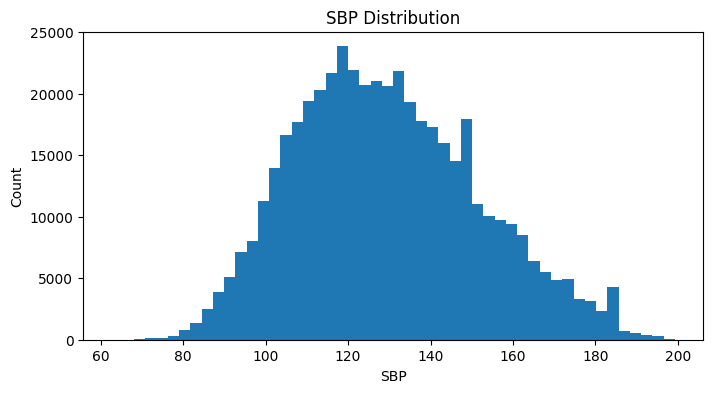

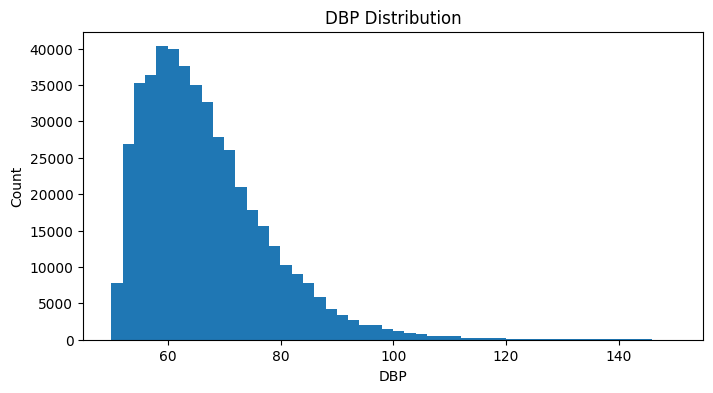

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(y_train[:,0], bins=50)
plt.xlabel("SBP")
plt.ylabel("Count")
plt.title("SBP Distribution")
plt.show()


plt.figure(figsize=(8,4))
plt.hist(y_train[:,1], bins=50)
plt.xlabel("DBP")
plt.ylabel("Count")
plt.title("DBP Distribution")
plt.show()

In [12]:
class PPGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [13]:
train_dataset = PPGDataset(
    X_train,
    y_train
)

val_dataset = PPGDataset(
    X_val,
    y_val
)

test_dataset = PPGDataset(
    X_test,
    y_test
)

In [14]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [15]:
x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([64, 1, 1000])
torch.Size([64, 2])


In [16]:
from models.CNN1D import CNN1D


model = CNN1D()

criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [18]:
model = model.to(device)

In [21]:
import numpy as np

EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/50 | Train MSE: 2923.81 (SBP RMSE: 48.89, DBP RMSE: 23.09) | Val MSE: 661.69 (SBP RMSE: 23.07, DBP RMSE: 11.38)
Epoch 2/50 | Train MSE: 795.27 (SBP RMSE: 24.95, DBP RMSE: 13.15) | Val MSE: 505.90 (SBP RMSE: 20.01, DBP RMSE: 10.28)
Epoch 3/50 | Train MSE: 754.56 (SBP RMSE: 24.29, DBP RMSE: 12.83) | Val MSE: 505.15 (SBP RMSE: 20.06, DBP RMSE: 10.14)
Epoch 4/50 | Train MSE: 734.76 (SBP RMSE: 23.99, DBP RMSE: 12.62) | Val MSE: 498.09 (SBP RMSE: 19.94, DBP RMSE: 10.02)
Epoch 5/50 | Train MSE: 715.78 (SBP RMSE: 23.69, DBP RMSE: 12.44) | Val MSE: 489.62 (SBP RMSE: 19.74, DBP RMSE: 10.01)
Epoch 6/50 | Train MSE: 702.59 (SBP RMSE: 23.46, DBP RMSE: 12.34) | Val MSE: 500.74 (SBP RMSE: 19.88, DBP RMSE: 10.27)
Epoch 7/50 | Train MSE: 690.54 (SBP RMSE: 23.23, DBP RMSE: 12.28) | Val MSE: 481.71 (SBP RMSE: 19.58, DBP RMSE: 9.91)
Epoch 8/50 | Train MSE: 683.07 (SBP RMSE: 23.09, DBP RMSE: 12.24) | Val MSE: 489.21 (SBP RMSE: 19.73, DBP RMSE: 9.99)
Epoch 9/50 | Train MSE: 672.45 (SBP RMSE: 22.90, 

## Observation ##
-> Training good + Validation bad  -> OVERFITTING
    
    - Regularisation
    - Change scheduler


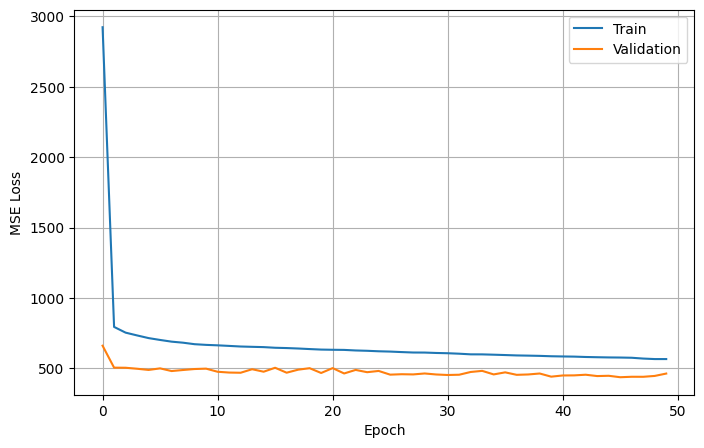

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [24]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 14.43 mmHg
DBP MAE: 7.03 mmHg


In [25]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 18.75 mmHg
DBP RMSE: 9.86 mmHg


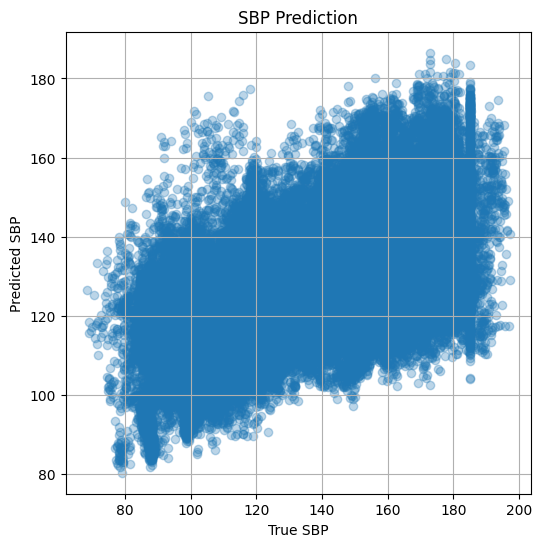

In [26]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

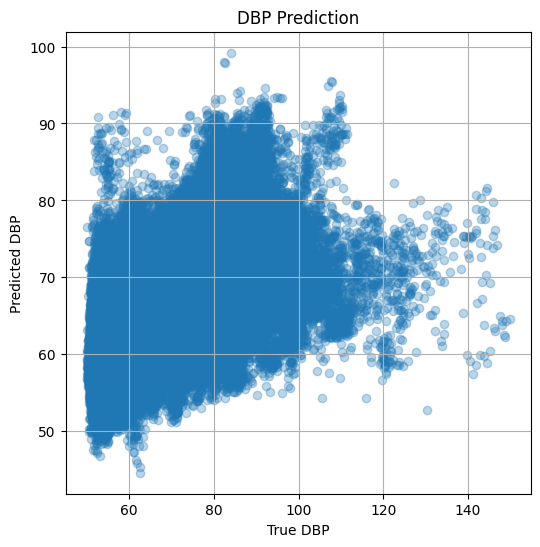

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()

In [28]:
import numpy as np

EPOCHS = 100

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/100 | Train MSE: 564.48 (SBP RMSE: 21.00, DBP RMSE: 11.11) | Val MSE: 463.76 (SBP RMSE: 19.22, DBP RMSE: 9.70)
Epoch 2/100 | Train MSE: 562.33 (SBP RMSE: 20.97, DBP RMSE: 11.07) | Val MSE: 438.38 (SBP RMSE: 18.67, DBP RMSE: 9.48)
Epoch 3/100 | Train MSE: 562.09 (SBP RMSE: 20.97, DBP RMSE: 11.07) | Val MSE: 468.93 (SBP RMSE: 19.30, DBP RMSE: 9.83)
Epoch 4/100 | Train MSE: 559.97 (SBP RMSE: 20.92, DBP RMSE: 11.07) | Val MSE: 437.95 (SBP RMSE: 18.64, DBP RMSE: 9.51)
Epoch 5/100 | Train MSE: 557.65 (SBP RMSE: 20.88, DBP RMSE: 11.04) | Val MSE: 431.49 (SBP RMSE: 18.49, DBP RMSE: 9.47)
Epoch 6/100 | Train MSE: 556.20 (SBP RMSE: 20.85, DBP RMSE: 11.02) | Val MSE: 440.22 (SBP RMSE: 18.61, DBP RMSE: 9.70)
Epoch 7/100 | Train MSE: 555.82 (SBP RMSE: 20.85, DBP RMSE: 11.01) | Val MSE: 436.21 (SBP RMSE: 18.58, DBP RMSE: 9.55)
Epoch 8/100 | Train MSE: 552.47 (SBP RMSE: 20.78, DBP RMSE: 10.98) | Val MSE: 443.34 (SBP RMSE: 18.83, DBP RMSE: 9.42)
Epoch 9/100 | Train MSE: 550.39 (SBP RMSE: 20.75

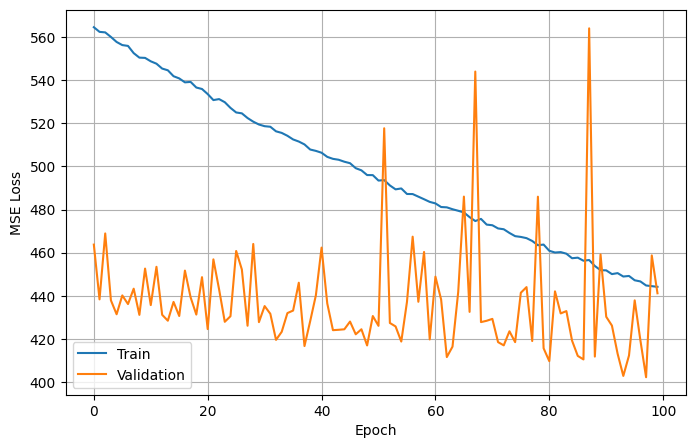

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [30]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [31]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 14.05 mmHg
DBP MAE: 7.36 mmHg


In [32]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 18.18 mmHg
DBP RMSE: 9.82 mmHg


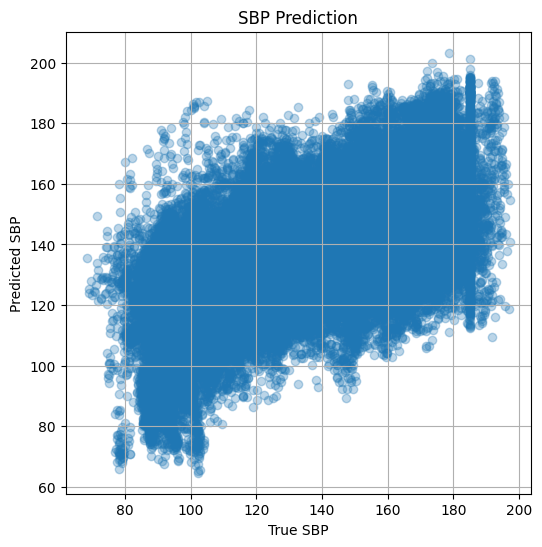

In [33]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

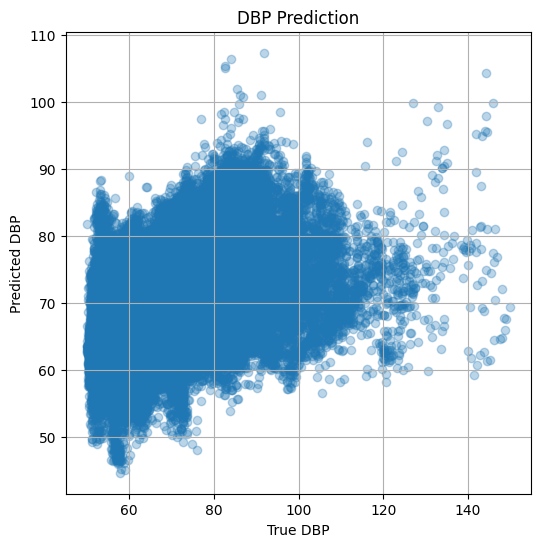

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()

Normalizing the output to help the model learn faster and stabilise the gradients

In [19]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([468372, 1, 1000])
torch.Size([468372, 2])
torch.Size([52933, 1, 1000])
torch.Size([52933, 2])
torch.Size([133841, 1, 1000])
torch.Size([133841, 2])


In [20]:
import numpy as np


# Mean and standard deviation of BP targets

y_mean = y_train.mean(axis=0)

y_std = y_train.std(axis=0)


print("SBP mean:", y_mean[0])
print("SBP std :", y_std[0])

print("DBP mean:", y_mean[1])
print("DBP std :", y_std[1])

SBP mean: tensor(129.5934)
SBP std : tensor(22.2738)
DBP mean: tensor(66.7786)
DBP std : tensor(11.2347)


In [21]:
y_train_norm = (
    y_train - y_mean
) / y_std


y_val_norm = (
    y_val - y_mean
) / y_std


y_test_norm = (
    y_test - y_mean
) / y_std

In [22]:
y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)

/tmp/ipykernel_313198/2247437078.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
/tmp/ipykernel_313198/2247437078.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
/tmp/ipykernel_313198/2247437078.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)


In [23]:
train_dataset = PPGDataset(
    X_train,
    y_train_norm
)

val_dataset = PPGDataset(
    X_val,
    y_val_norm
)

test_dataset = PPGDataset(
    X_test,
    y_test_norm
)

In [24]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [26]:
EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/50 | Train MSE: 1.63 (SBP RMSE: 0.89, DBP RMSE: 0.92) | Val MSE: 1.52 (SBP RMSE: 0.88, DBP RMSE: 0.87)
Epoch 2/50 | Train MSE: 1.49 (SBP RMSE: 0.85, DBP RMSE: 0.88) | Val MSE: 1.54 (SBP RMSE: 0.88, DBP RMSE: 0.87)
Epoch 3/50 | Train MSE: 1.43 (SBP RMSE: 0.83, DBP RMSE: 0.86) | Val MSE: 1.44 (SBP RMSE: 0.85, DBP RMSE: 0.84)
Epoch 4/50 | Train MSE: 1.39 (SBP RMSE: 0.81, DBP RMSE: 0.85) | Val MSE: 1.48 (SBP RMSE: 0.86, DBP RMSE: 0.86)
Epoch 5/50 | Train MSE: 1.36 (SBP RMSE: 0.80, DBP RMSE: 0.84) | Val MSE: 1.42 (SBP RMSE: 0.85, DBP RMSE: 0.84)
Epoch 6/50 | Train MSE: 1.33 (SBP RMSE: 0.80, DBP RMSE: 0.84) | Val MSE: 1.40 (SBP RMSE: 0.84, DBP RMSE: 0.84)
Epoch 7/50 | Train MSE: 1.31 (SBP RMSE: 0.79, DBP RMSE: 0.83) | Val MSE: 1.37 (SBP RMSE: 0.83, DBP RMSE: 0.82)
Epoch 8/50 | Train MSE: 1.30 (SBP RMSE: 0.78, DBP RMSE: 0.83) | Val MSE: 1.43 (SBP RMSE: 0.84, DBP RMSE: 0.85)
Epoch 9/50 | Train MSE: 1.28 (SBP RMSE: 0.78, DBP RMSE: 0.82) | Val MSE: 1.35 (SBP RMSE: 0.82, DBP RMSE: 0.82)
E

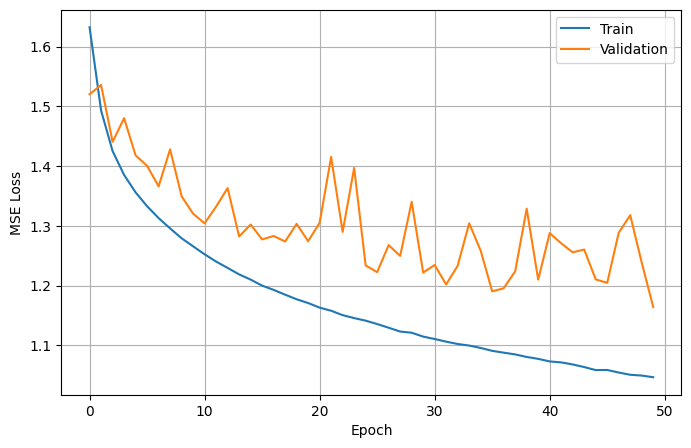

In [27]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [28]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [29]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 0.56 mmHg
DBP MAE: 0.57 mmHg


In [30]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 0.75 mmHg
DBP RMSE: 0.80 mmHg


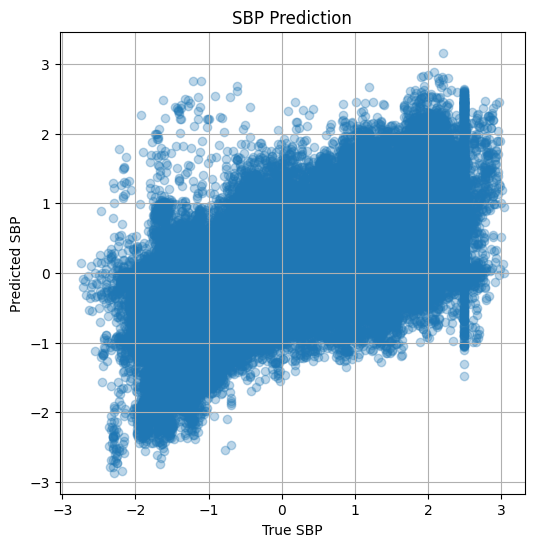

In [31]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

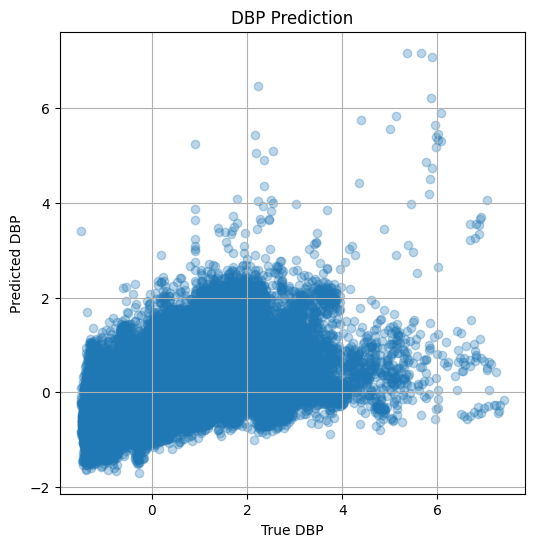

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()

In [33]:
EPOCHS = 100

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/100 | Train MSE: 1.04 (SBP RMSE: 0.70, DBP RMSE: 0.75) | Val MSE: 1.26 (SBP RMSE: 0.80, DBP RMSE: 0.79)
Epoch 2/100 | Train MSE: 1.04 (SBP RMSE: 0.70, DBP RMSE: 0.75) | Val MSE: 1.35 (SBP RMSE: 0.81, DBP RMSE: 0.84)
Epoch 3/100 | Train MSE: 1.04 (SBP RMSE: 0.69, DBP RMSE: 0.75) | Val MSE: 1.16 (SBP RMSE: 0.77, DBP RMSE: 0.76)
Epoch 4/100 | Train MSE: 1.04 (SBP RMSE: 0.69, DBP RMSE: 0.75) | Val MSE: 1.18 (SBP RMSE: 0.76, DBP RMSE: 0.77)
Epoch 5/100 | Train MSE: 1.03 (SBP RMSE: 0.69, DBP RMSE: 0.74) | Val MSE: 1.17 (SBP RMSE: 0.77, DBP RMSE: 0.76)
Epoch 6/100 | Train MSE: 1.03 (SBP RMSE: 0.69, DBP RMSE: 0.74) | Val MSE: 1.24 (SBP RMSE: 0.78, DBP RMSE: 0.79)
Epoch 7/100 | Train MSE: 1.03 (SBP RMSE: 0.69, DBP RMSE: 0.74) | Val MSE: 1.17 (SBP RMSE: 0.76, DBP RMSE: 0.77)
Epoch 8/100 | Train MSE: 1.03 (SBP RMSE: 0.69, DBP RMSE: 0.74) | Val MSE: 1.24 (SBP RMSE: 0.78, DBP RMSE: 0.80)
Epoch 9/100 | Train MSE: 1.03 (SBP RMSE: 0.69, DBP RMSE: 0.74) | Val MSE: 1.19 (SBP RMSE: 0.76, DBP RMSE

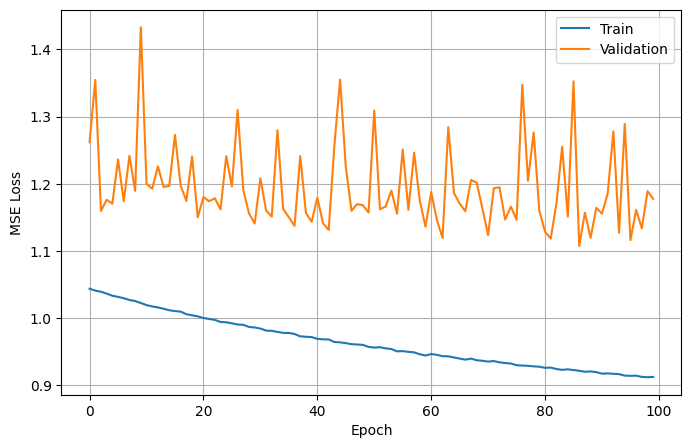

In [34]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [40]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.cpu().numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


# ------------------------------------
# Denormalize back to mmHg
# ------------------------------------
y_mean = y_mean.cpu().numpy()
y_std = y_std.cpu().numpy()
predictions = predictions * y_std + y_mean
targets = targets * y_std + y_mean


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

print("\nFirst 5 Predictions (mmHg):")
print(predictions[:5])

print("\nFirst 5 Targets (mmHg):")
print(targets[:5])

Predictions shape: (133841, 2)
Targets shape: (133841, 2)

First 5 Predictions (mmHg):
[[135.55968  68.62763]
 [130.67049  64.14827]
 [134.44504  66.90769]
 [136.27055  66.87838]
 [137.35945  66.12552]]

First 5 Targets (mmHg):
[[143.30846   60.371254]
 [142.83955   58.99385 ]
 [143.4843    60.40056 ]
 [149.11113   61.57282 ]
 [152.39346   61.54351 ]]


In [41]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 12.26 mmHg
DBP MAE: 6.28 mmHg


In [42]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 16.44 mmHg
DBP RMSE: 8.94 mmHg


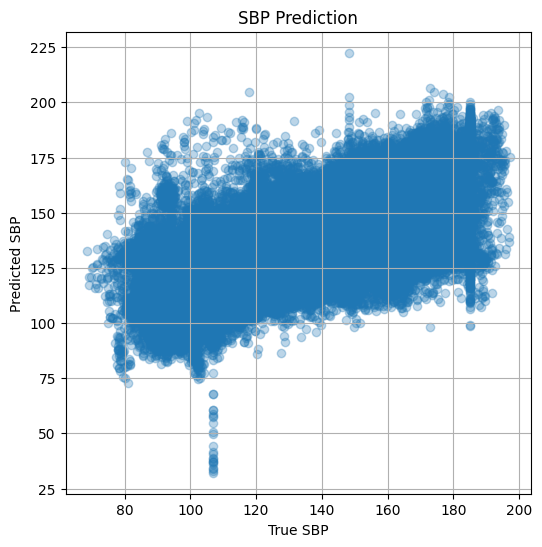

In [43]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

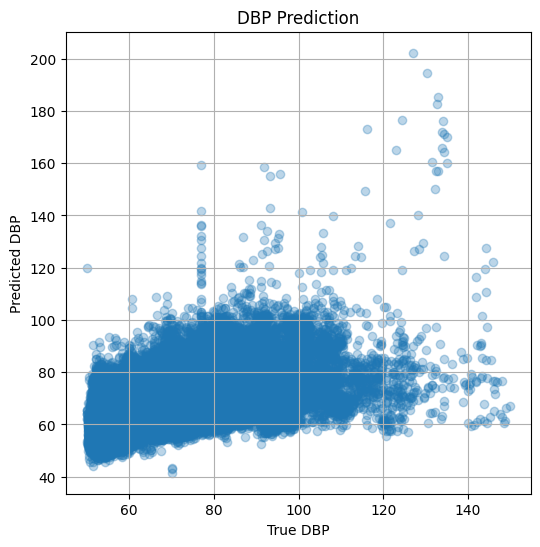

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()